In [88]:
import numpy as np
import pandas as pd
import pyopenms as ms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from itertools import product
import string

# generate data table
Peptide sequences from library generation, generate [M+H]+ and [M+2H]2+

In [5]:
curated_library_unirep = np.load('data/curated_peptide_list.npy')

#Define modifications
linear = 'TAPAYDG'
lin_het_red = 'T[-18.01]APAYDG'
lin_het_ox = 'T[-20.02]APAYDG'
cyc = "TAP[-18.01]"
mods = [linear, lin_het_red, lin_het_ox, cyc]

# create pandas dataframe containing peptide seqs and their mass
df = pd.DataFrame(columns = ['linear', 'L(m+1)', 'L(m+2)', 'L(m+3)',
                             'lin+het+red', 'LHR(m+1)', 'LHR(m+2)','LHR(m+3)', 
                             'lin+het+ox', 'LHO(m+1)', 'LHO(m+2)','LHO(m+3)', 
                             'cyclic', 'C(m+1)', 'C(m+2)', 'C(m+3)'])

for j, pep in enumerate(curated_library_unirep):
    d = []
    for suffix in mods:
        seq_str = pep + suffix
        d.append(seq_str)
        seq = ms.AASequence.fromString(seq_str)
        for i in range(1,4):
            d.append(seq.getMonoWeight(ms.Residue.ResidueType.Full, int(i))/float(i))
    df.loc[j] = d

In [8]:
df.to_csv('data/peptide_mass_table.csv')
df.head()
df.iloc[63]

linear                 KYLKVTAPAYDG
L(m+1)                  1325.709986
L(m+2)                   663.358631
L(m+3)                   442.574846
lin+het+red    KYLKVT[-18.01]APAYDG
LHR(m+1)                 1307.69942
LHR(m+2)                 654.353348
LHR(m+3)                 436.571324
lin+het+ox     KYLKVT[-20.02]APAYDG
LHO(m+1)                1305.689986
LHO(m+2)                 653.348631
LHO(m+3)                 435.901513
cyclic             KYLKVTAP[-18.01]
C(m+1)                   901.550569
C(m+2)                   451.278923
C(m+3)                   301.188374
Name: 63, dtype: object

In [14]:
def extract_ioncount(exp, ions, rt_start, rt_end, MZ_tol=0.1):
    '''
    returns list of extracted ion counts of an mzML
    exp : [pyOpenMS experiment]
    ions: iterable of desired ion m/z values [float]
    rt_start: start acquisition retentiontime [seconds]
    rt_end: end acquisition retentiontime [seconds]
    MZ_tol: tolerance interval for m/z [float]
    '''
    N_scans = len(exp.getSpectra())
    ionCounts = np.zeros(len(ions))
    if PLOT==True:
        intensity = np.zeros((len(ions), N_scans))
    else: 
        intensity = None
        
    for j, ion in enumerate(ions):
        for i in range(N_scans):
            rt = exp.getSpectrum(i).getRT()
            if (rt>rt_start) and (rt<rt_end):
                mass, count = exp.getSpectrum(i).get_peaks()
                mask = (mass > (ion - MZ_tol)) & (mass < (ion + MZ_tol))
                ic = count[mask].sum()
                ionCounts[j] += ic
                
                if PLOT==True:
                    intensity[j,i] = ic
         
    return(list(ionCounts), intensity)

In [15]:
PLOT=False
data_dir = 'data/PatG-2d/'
infiles = os.listdir(data_dir)
infiles = [data_dir+i for i in infiles if i.endswith('mzML') == True]

# define ions relevant for experiment type (which ions are relevant to observe)
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
cyclic_ions =  ['C(m+1)', 'C(m+2)', 'C(m+3)']
exp_ions = linear_ions + cyclic_ions

result_df = pd.DataFrame(columns=['peptide']+exp_ions)

# range of elution time that should be scanned
start = 60
end = 240

In [16]:
for infile in infiles:
    exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
    ions = df.loc[exp_num, exp_ions] # get the defined ions
    peptide = df.loc[exp_num, 'linear'] # get peptide sequence
    
    exp = ms.MSExperiment()
    ms.MzMLFile().load(infile, exp)
    
    ion_count, intensity = extract_ioncount(exp, ions, start, end)
    
    if PLOT==True:
        for i in range(len(ions)):
            col = ['r', 'b']
            if i <= 3: 
                plt.plot(intensity[i], color = col[0])
            else:
                plt.plot(intensity[i], color = col[1])
        plt.xlabel('Scans')
        plt.ylabel('Intensity')
        plt.title('PatG + '+peptide)
        red_patch = mpatches.Patch(color='red', label='linear peptide')
        blue_patch = mpatches.Patch(color='blue', label='cyclic peptide')
        plt.legend(loc='upper right', handles=[red_patch, blue_patch])
        plt.savefig('output_patg/'+str(exp_num)+'_PatG_'+peptide)
        plt.clf()
            
    result_df.loc[exp_num] = [peptide]+ion_count

# sum up ion counts of +1 to +3 charge states
result_df['L(tot)'] = result_df.loc[:,['L(m+1)', 'L(m+2)', 'L(m+3)']].sum(axis=1)
result_df['C(tot)'] = result_df.loc[:,['C(m+1)', 'C(m+2)', 'C(m+3)']].sum(axis=1)

# calculate conversion in % of cyclic to total product+starting material
result_df['conversion'] = result_df.loc[:,'C(tot)']/result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)*100

In [17]:
result_df.sort_index(inplace=True)
result_df['tot_ions'] = result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)
result_df.head()

,peptide,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,tot_ions
0,DVQAFTAPAYDG,7531874.0,19668994.0,58639.0,90305.0,69820.0,2580.0,27259507.0,162705.0,0.593333,27422212.0
1,GYLKWTAPAYDG,1461095.0,24657199.0,446022.0,535403.0,546919.0,8236.0,26564316.0,1090558.0,3.943457,27654874.0
2,GAEWRTAPAYDG,1017100.0,22715978.0,545006.0,62197.0,262824.0,2020.0,24278084.0,327041.0,1.329158,24605125.0
3,IDFVKTAPAYDG,2002792.0,39992257.0,950171.0,132742.0,167436.0,3157.0,42945220.0,303335.0,0.701376,43248555.0
4,WLYKDTAPAYDG,1185543.0,33413060.0,800418.0,600039.0,748721.0,5307.0,35399021.0,1354067.0,3.684226,36753088.0


In [69]:
result_df.sort_values('tot_ions').head(20)


,peptide,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,tot_ions
37,ERVQKTAPAYDG,3219.0,94661.0,566178.0,34990.0,289788.0,13591.0,664058.0,338369.0,1.000000e-08,1.000000e-08
77,GFDKWTAPAYDG,110.0,4273.0,5799.0,2434.0,1864.0,4876.0,10182.0,9174.0,1.000000e-08,1.000000e-08
39,TAASITAPAYDG,638.0,7212.0,4054.0,1544.0,21586.0,2298.0,11904.0,25428.0,1.000000e-08,1.000000e-08
21,VYREKTAPAYDG,2607.0,95348.0,654617.0,12419.0,142548.0,6276.0,752572.0,161243.0,1.000000e-08,1.000000e-08
40,NFRAFTAPAYDG,101.0,2548.0,5944.0,606.0,5298.0,2028.0,8593.0,7932.0,1.000000e-08,1.000000e-08
86,EYWNATAPAYDG,0.0,16649.0,5500.0,1944.0,7883.0,2670.0,22149.0,12497.0,1.000000e-08,1.000000e-08
88,YEIAYTAPAYDG,343.0,2613.0,3577.0,872.0,3781.0,31791.0,6533.0,36444.0,1.000000e-08,1.000000e-08
65,ARYFQTAPAYDG,212.0,3321.0,2375.0,787.0,1389.0,1211.0,5908.0,3387.0,1.000000e-08,1.000000e-08
63,KYLKVTAPAYDG,471.0,142862.0,982.0,1069.0,5920.0,468022.0,144315.0,475011.0,1.000000e-08,1.000000e-08
62,GKTRLTAPAYDG,548.0,1950.0,10044.0,2062.0,8387.0,22041.0,12542.0,32490.0,1.000000e-08,1.000000e-08


In [20]:
result_df.describe()

,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,1.195431e+06,1.691011e+07,3.663402e+06,4.151549e+05,1.054234e+06,30788.739583,2.176894e+07,1.500178e+06,11.670124,2.326912e+07
std,2.318808e+06,1.205396e+07,8.294074e+06,1.092042e+06,2.539245e+06,67359.997388,1.334970e+07,3.187053e+06,18.864921,1.477855e+07
min,0.000000e+00,1.629000e+03,9.820000e+02,6.060000e+02,1.286000e+03,1206.000000,4.061000e+03,3.387000e+03,0.336434,9.295000e+03
25%,1.714785e+05,6.870672e+06,1.389520e+05,6.175550e+04,8.790850e+04,2802.000000,1.042829e+07,2.226730e+05,1.552658,1.086338e+07
50%,6.981210e+05,1.655586e+07,6.370090e+05,1.176550e+05,2.741430e+05,7894.000000,2.423789e+07,4.938055e+05,3.808315,2.460382e+07
75%,1.161805e+06,2.635506e+07,1.127148e+06,3.509852e+05,1.005892e+06,21890.250000,3.314439e+07,1.422624e+06,10.501439,3.504491e+07
max,1.857161e+07,4.083634e+07,3.387789e+07,9.628068e+06,1.799049e+07,468022.000000,4.494400e+07,2.038815e+07,84.798846,6.517994e+07


Text(0, 0.5, '% conversion')

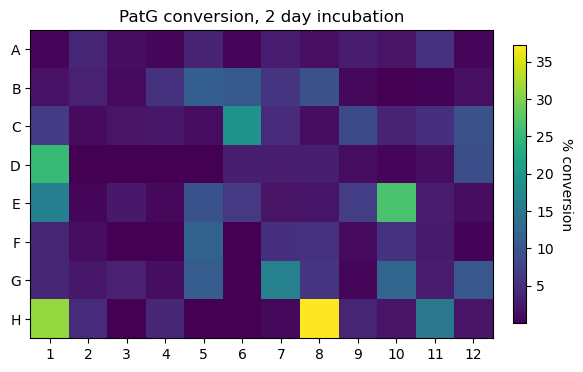

In [87]:
rows = list(string.ascii_uppercase[:8])
cols = list(range(1,13))
quantity = 'conversion'

mask = result_df['tot_ions'] < 1739627.0
data = result_df.loc[:, quantity]
#data[mask] = 0.00000001
data = np.array(data).reshape((8,12))

fig, ax = plt.subplots()
im = ax.imshow(data)
ax.set_xticks(np.arange(len(cols)), labels=cols)
ax.set_yticks(np.arange(len(rows)), labels=rows)
plt.title('PatG conversion, 2 day incubation')
cbar = ax.figure.colorbar(im, ax=ax, fraction=0.028, pad=0.04)

cbar.ax.set_ylabel('% '+quantity, rotation=-90, va="bottom")